# `SurfTrack`: temporal-neighbour labelling and overlap threshold

`SurfTrack` operates on 3-D data `(time, lat, lon)` and runs four steps:

1. **Morphological close→open** cleans each 2-D slice independently
2. **Area filtering** removes objects below a size threshold
3. **Labelling** — two methods are available:
   - `method='3d'` runs connected-component labelling on the full `(time, lat, lon)` volume at once. Blobs can link across any number of timesteps as long as there is an unbroken 3-D path, including diagonal connections through time. This is the default.
   - `method='temporal_neighbor'` labels each 2-D frame independently, then only links blobs between adjacent frames if they meet a spatial overlap criterion. A gap of even one timestep starts a new event.
4. **Date-line wrapping** merges events that straddle the 0°/360° boundary

For subsurface (4-D) tracking see the **DeepTrack** tutorial.


### 1. Imports

In [ ]:
# in the environment do pip install -e ocetrac
#nfrom the right environment

In [2]:
from ocetrac.SurfTrack import SurfTracker
from ocetrac.SurfTrack.tracker import label_temporal_neighbor, wrap_labels
from ocetrac.preprocessing.cesm2_lens_utils import get_ds_var
from ocetrac.preprocessing.preprocessing import calculate_anomalies_trend_features

In [3]:
import numpy as np
import xarray as xr

import cmocean
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from skimage.measure import label as label_np
import scipy
from scipy import ndimage

import warnings
warnings.filterwarnings("ignore", message=".*decode the variable.*")
warnings.filterwarnings("ignore", message=".*default value for data_vars.*")

### 2. Data loading

Loads CESM2 Large Ensemble (CESM2-LENS) SST data for a single ensemble member.
The CESM2-LE provides 100 members spanning 1850–2100.

- Variable: `SST` (sea surface temperature)
- Component: `atm`
- Temporal resolution: monthly means
- Spatial domain: 65°S–65°N


In [4]:
%%time

ens_memb_index = 0
var, comp  = 'SST', 'atm'
directory  = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'

ds_hist, _ = get_ds_var(directory, var, comp, ens_memb_index)

da_sst = ds_hist[var].sel(
    lat=slice(-65, 65),
    time=slice('1979-01', '2015-01')).compute()

print(f"Loaded: {da_sst.dims}  {da_sst.shape}")

Loaded: ('time', 'lat', 'lon')  (433, 138, 288)
CPU times: user 1.85 s, sys: 697 ms, total: 2.54 s
Wall time: 6.78 s


### 3. Anomaly computation

This step is separate from the tracking algorithm. It removes the long-term trend
and seasonal cycle from the SST field using a 6-coefficient harmonic model fit per
grid cell. The residual (`features`) is what gets tracked.

The threshold `0.9` flags grid cells where the anomaly exceeds the 90th percentile
of the local distribution.


In [5]:
%%time

mean, trend, seas, features, anom = calculate_anomalies_trend_features(da_sst, 0.9)

print(f"features shape: {features.shape}  ({features.nbytes/1e9:.2f} GB)")

features shape: (433, 138, 288)  (0.14 GB)
CPU times: user 1.4 s, sys: 75.3 ms, total: 1.48 s
Wall time: 1.7 s


In [6]:
# Subset to 40 timesteps for this tutorial
features = features.isel(time=slice(40))
print(f"Tutorial subset: {features.shape}")

Tutorial subset: (40, 138, 288)


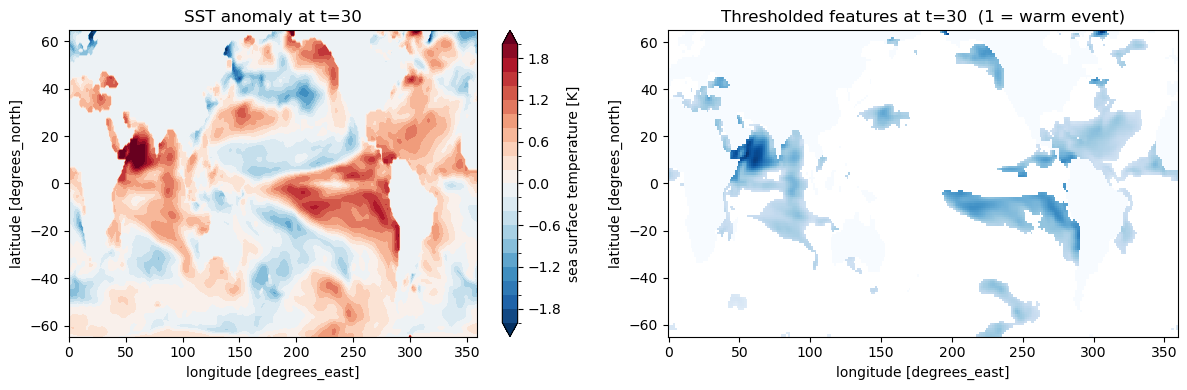

In [7]:
# Quick look: anomaly temperature vs thresholded features at one timestep
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

anom.isel(time=30).plot.contourf(
    ax=ax1, levels=21, vmin=-2, vmax=2, cmap='RdBu_r', add_colorbar=True)
ax1.set_title('SST anomaly at t=30')

features.isel(time=30).plot(
    ax=ax2, cmap='Blues', add_colorbar=False)
ax2.set_title('Thresholded features at t=30  (1 = warm event)')

plt.tight_layout()
plt.show()

### 4. Ocean mask

The mask defines which grid cells are valid ocean (1) and which are land or
other ignored regions (0). It is derived directly from the SST field — cells
where SST is exactly 0 are treated as land.


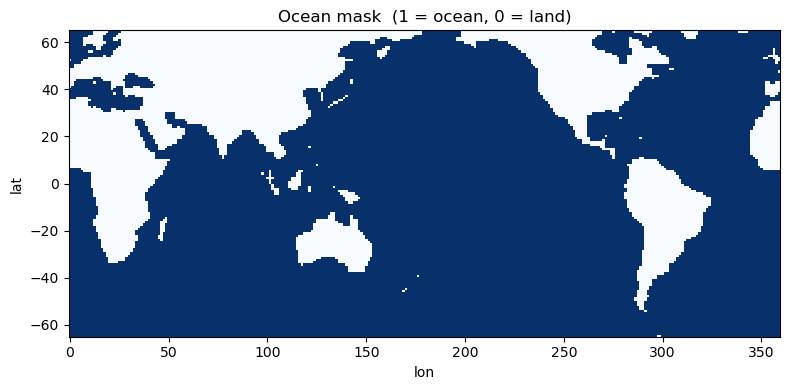

In [8]:
mask = xr.where(da_sst[0, :, :] == 0., 0., 1.)

fig, ax = plt.subplots(figsize=(8, 4))
mask.plot(ax=ax, cmap='Blues', add_colorbar=False)
ax.set_title('Ocean mask  (1 = ocean, 0 = land)')
plt.tight_layout()
plt.show()

### 5. Initialise and run the tracker

#### Parameters

| Parameter | Description |
|---|---|
| `radius` | Structuring element radius for morphological close→open. Larger values fill wider gaps but risk bridging nearby separate events. |
| `min_size_quartile` | Drop blobs below this percentile of the area distribution. Combined with `min_area_cells` via `max()`. |
| `min_area_cells` | Absolute minimum blob size in grid cells. Always applied regardless of the percentile. |
| `positive` | `True` → track warm anomalies; `False` → cold. |
| `method` | `"3d"` (default) or `"temporal_neighbor"`. |
| `contain_thresh` | `method="temporal_neighbor"` only. Containment threshold for merging blobs across timesteps. |

#### The `contain_thresh` parameter

Two blobs — one at time $t$ and one at $t+1$ — are merged into the same event only if:

$$\max\left(\frac{|A \cap B|}{|A|},\ \frac{|A \cap B|}{|B|}\right) \geq \text{contain\_thresh}$$

This is the maximum of the fraction of $A$ covered by $B$ and the fraction of $B$ covered by $A$.
A small blob that is almost entirely inside a large blob will merge even if the large blob barely
notices the overlap — which is the right physical behaviour for a shrinking or growing feature.

| `contain_thresh` | Behaviour |
|---|---|
| `0.0` (default) | Any single pixel of overlap merges the two blobs |
| `0.3` | One blob must cover at least 30% of the other |
| `0.6` | One blob must cover at least 60% of the other — stricter |
| `1.0` | One blob must be entirely inside the other |

Higher threshold → stricter → less merging → more events.


#### Run `method='temporal_neighbor'`

In [9]:
%%time

tracker_tn = SurfTracker(
    features,
    mask,
    radius=2,
    min_size_quartile=0.25,
    min_area_cells=100,
    timedim='time',
    xdim='lon',
    ydim='lat',
    method='temporal_neighbor',
    contain_thresh=0.6,
)
result_tn = tracker_tn.run()
tracker_tn.summary()

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)
Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)
Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 103
Step 4 · wrapping result …
SurfTracker — Result Summary
  Input shape    : (40, 138, 288)
  Tracked events : 103
  Duration  min/median/max : 1 / 1 / 20
    >=  1 ts : 103
    >=  3 ts : 29
    >=  6 ts : 9
    >= 12 ts : 4

  Parameters:
    radius               = 2
    min_area_cells       = 100
    min_size_quartile    = 0.25
    positive             = True
    method               = temporal_neighbor
    contain_thresh       = 0.6
CPU times: user 1.07 s, sys: 23.2 ms, total: 1.1 s
Wall time: 1.17 s


In [10]:
print("Result attributes:")
for k, v in result_tn.attrs.items():
    print(f"  {k:<30} {v}")

Result attributes:
  initial objects identified     791
  final objects tracked          103
  radius                         2
  size quantile threshold        0.25
  min area cells                 100
  min area (effective)           100.0
  percent area reject            0.10522655374881522
  percent area accept            0.8947734462511848
  method                         temporal_neighbor
  contain_thresh                 0.6


#### Run `method='3d'` (default) for comparison

`method='3d'` is the original SurfTrack algorithm. It serves as the baseline here.
Because it can bridge gaps diagonally through the 3-D volume, it tends to produce
fewer but longer events than `temporal_neighbor`.


In [11]:
%%time

tracker_3d = SurfTracker(
    features,
    mask,
    radius=2,
    min_size_quartile=0.25,
    min_area_cells=100,
    timedim='time',
    xdim='lon',
    ydim='lat',
    method='3d',
)
result_3d = tracker_3d.run()
tracker_3d.summary()

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)
Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)
Step 3 · labelling (method='3d') …
    initial objects : 791
    final objects   : 60
Step 4 · wrapping result …
SurfTracker — Result Summary
  Input shape    : (40, 138, 288)
  Tracked events : 60
  Duration  min/median/max : 1 / 1 / 22
    >=  1 ts : 60
    >=  3 ts : 20
    >=  6 ts : 11
    >= 12 ts : 5

  Parameters:
    radius               = 2
    min_area_cells       = 100
    min_size_quartile    = 0.25
    positive             = True
    method               = 3d
    contain_thresh       = 0.0
CPU times: user 1.14 s, sys: 39.6 ms, total: 1.18 s
Wall time: 1.29 s


In [12]:
print("Result attributes:")
for k, v in result_3d.attrs.items():
    print(f"  {k:<30} {v}")

Result attributes:
  initial objects identified     791
  final objects tracked          60
  radius                         2
  size quantile threshold        0.25
  min area cells                 100
  min area (effective)           100.0
  percent area reject            0.10522655374881522
  percent area accept            0.8947734462511848
  method                         3d
  contain_thresh                 0.0


#### Method comparison summary


In [13]:
n_tn = tracker_tn.n_events()
n_3d = tracker_3d.n_events()

print(f"{'Method':<30} {'Events':>8}")
print("-" * 40)
print(f"{'temporal_neighbor (thresh=0.6)':<30} {n_tn:>8}")
print(f"{'3d':<30} {n_3d:>8}")
print()
print(f"temporal_neighbor finds {n_tn - n_3d:+d} events relative to 3d")
print()
print("Key difference:")
print("  3d          : can bridge gaps diagonally → fewer, longer events")
print("  temp. neigh.: gap of 1 timestep = new event → more, shorter events")

Method                           Events
----------------------------------------
temporal_neighbor (thresh=0.6)      103
3d                                   60

temporal_neighbor finds +43 events relative to 3d

Key difference:
  3d          : can bridge gaps diagonally → fewer, longer events
  temp. neigh.: gap of 1 timestep = new event → more, shorter events


### 6. Inspect intermediate steps

Each pipeline step stores its output as an attribute on the tracker object so
you can inspect and plot the intermediate results without re-running the full pipeline.

| Step | Method called | Output attribute |
|---|---|---|
| 1 | `.clean()` | `tracker.binary_clean` |
| 2 | `.filter()` | `tracker.binary_filtered`, `tracker.area`, `tracker.min_area`, `tracker.N_initial` |
| 3 | `.track()` | `tracker.labels_unfilt` |
| 4 | `.postprocess()` | `tracker.result` |


In [14]:
tracker_tn = SurfTracker(
    features, mask,
    radius=2, min_size_quartile=0.25, min_area_cells=100,
    timedim='time', xdim='lon', ydim='lat',
    method='temporal_neighbor',
    contain_thresh=0.6,
)

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)


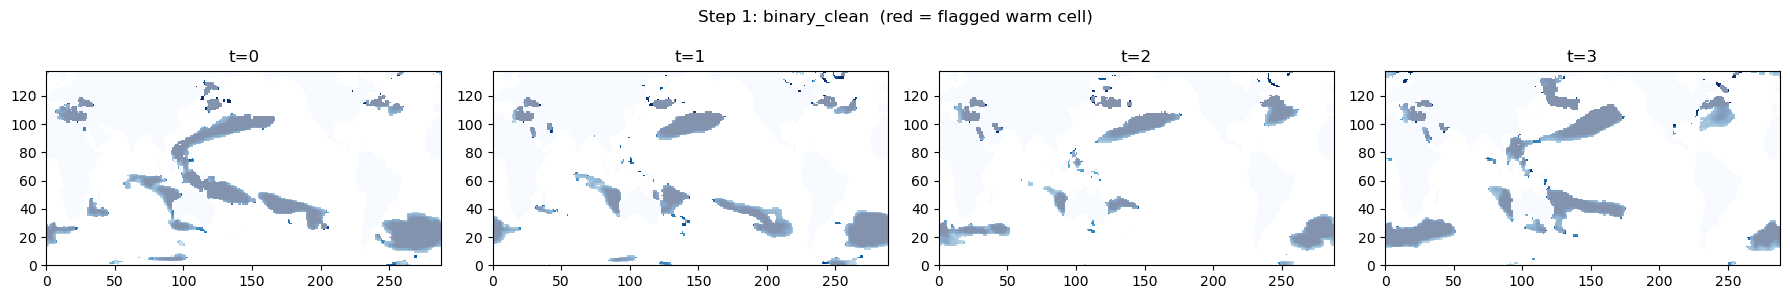

Fraction flagged: 0.1022


In [15]:
# Step 1 — morphological cleaning + masking
tracker_tn.clean()

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for t, ax in enumerate(axes):
    ax.pcolormesh(features.isel(time=t).values, cmap='Blues', vmin=0, vmax=1)
    ax.pcolormesh(np.where(tracker_tn.binary_clean.isel(time=t).values, 1, np.nan),
                  cmap='Reds', alpha=0.5)
    ax.set_title(f't={t}')
fig.suptitle('Step 1: binary_clean  (red = flagged warm cell)')
plt.tight_layout()
plt.show()

print(f"Fraction flagged: {float(tracker_tn.binary_clean.values.mean()):.4f}")

In [29]:
# Before wrap
labels_unfilt, n_unfilt = label_temporal_neighbor(tracker_tn.binary_clean, contain_thresh=0.6)
print("Before wrap:", np.unique(labels_unfilt[labels_unfilt > 0]))
print("n =", n_unfilt)

# After wrap
labels_wrapped, n_wrapped = wrap_labels(labels_unfilt.copy())
print("After wrap:", np.unique(labels_wrapped[labels_wrapped > 0]))
print("n =", n_wrapped)

Before wrap: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 2

Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)


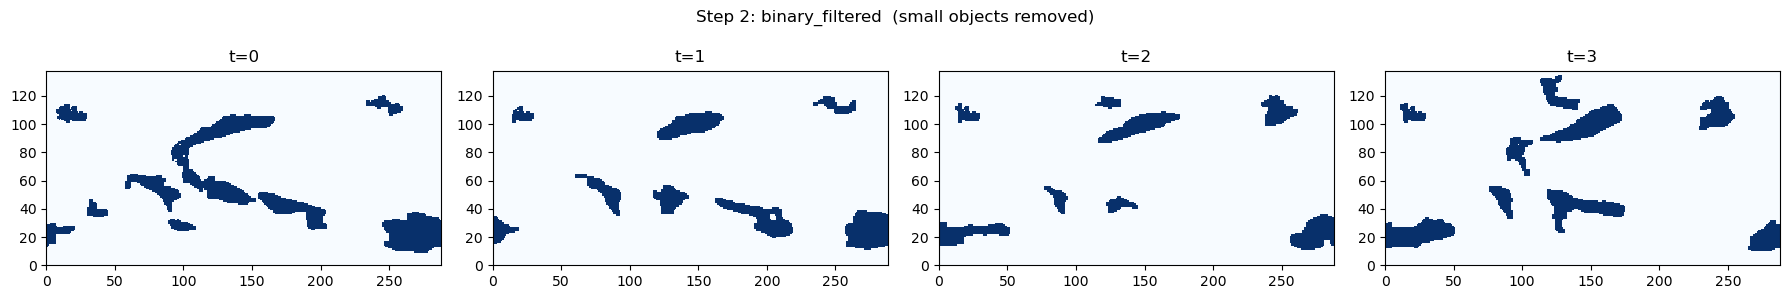

Area threshold  : 100 cells
Initial objects : 791
Area stats — min: 3  median: 61  max: 3682


In [30]:
# Step 2 — area filtering
tracker_tn.filter()

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for t, ax in enumerate(axes):
    ax.pcolormesh(tracker_tn.binary_filtered.isel(time=t).values, cmap='Blues')
    ax.set_title(f't={t}')
fig.suptitle('Step 2: binary_filtered  (small objects removed)')
plt.tight_layout()
plt.show()

print(f"Area threshold  : {tracker_tn.min_area:.0f} cells")
print(f"Initial objects : {tracker_tn.N_initial}")
print(f"Area stats — min: {float(tracker_tn.area.min()):.0f}  "
      f"median: {float(tracker_tn.area.median()):.0f}  "
      f"max: {float(tracker_tn.area.max()):.0f}")

In [32]:
tracker_tn.track()
print([attr for attr in dir(tracker_tn) if not attr.startswith('_')])

Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 103
['N_initial', 'area', 'binary_clean', 'binary_filtered', 'clean', 'contain_thresh', 'da', 'event_duration', 'filter', 'labels_raw', 'mask', 'method', 'min_area', 'min_area_cells', 'min_size_quartile', 'n_events', 'positive', 'postprocess', 'radius', 'result', 'run', 'summary', 'timedim', 'track', 'xdim', 'ydim']


Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 103


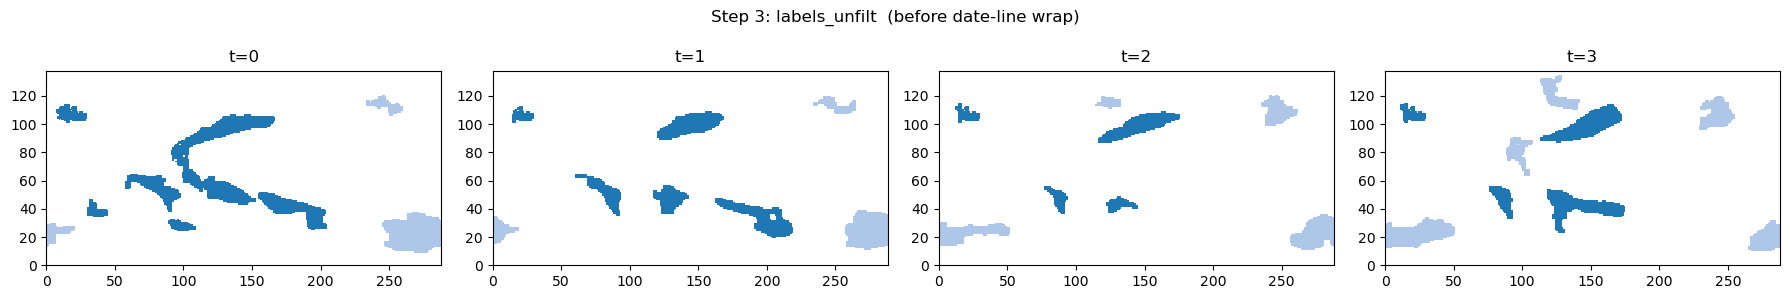

In [35]:
# Step 3 — labelling
tracker_tn.track()

n_unfilt = int(tracker_tn.labels_raw.max())
cmap_unfilt = plt.colormaps.get_cmap('tab20').resampled(n_unfilt + 2)

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for t, ax in enumerate(axes):
    unfilt = tracker_tn.labels_raw[t].astype(float)
    ax.pcolormesh(np.where(unfilt > 0, unfilt, np.nan), cmap=cmap_unfilt, vmin=1, vmax=n_unfilt)
    ax.set_title(f't={t}')
fig.suptitle('Step 3: labels_unfilt  (before date-line wrap)')
plt.tight_layout()
plt.show()

Step 4 · wrapping result …


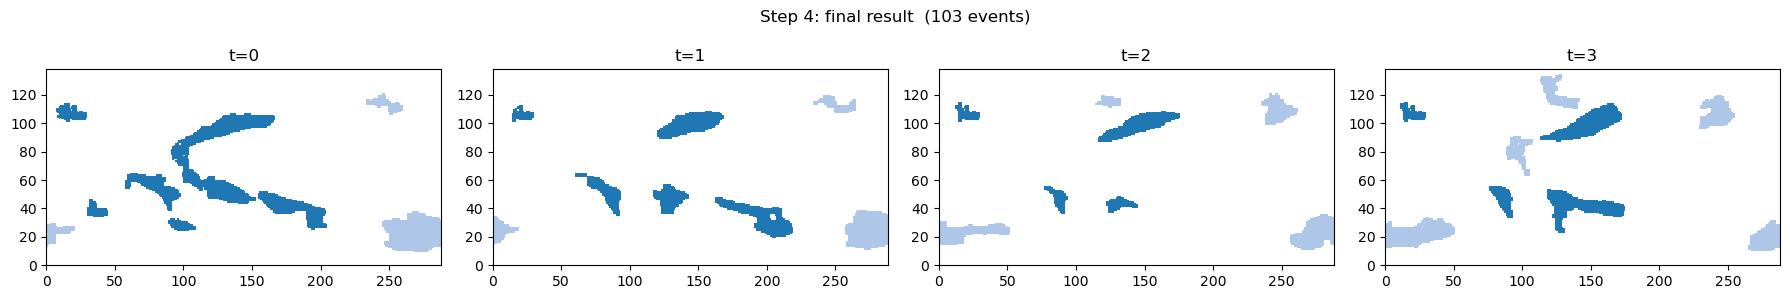

In [36]:
# Step 4 — postprocess
tracker_tn.postprocess()

n_ev = tracker_tn.n_events()
cmap_ev = plt.colormaps.get_cmap('tab20').resampled(n_ev + 2)

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for t, ax in enumerate(axes):
    res = tracker_tn.result.isel(time=t).values
    ax.pcolormesh(np.where(~np.isnan(res), res, np.nan), cmap=cmap_ev, vmin=1, vmax=n_ev)
    ax.set_title(f't={t}')
fig.suptitle(f'Step 4: final result  ({n_ev} events)')
plt.tight_layout()
plt.show()

### 7. Side-by-side maps

Compare event labels from `method='3d'` and `method='temporal_neighbor'` at the same
four timesteps. Same color = same event ID. Different colors for the same physical
feature across the two rows means the methods disagree on whether it is one event or two.


In [37]:
lon     = mask.lon.values
lat     = mask.lat.values
mask_2d = mask.values

# Build a shared colormap scaled to the larger event count
n_colors = max(tracker_3d.n_events(), tracker_tn.n_events()) + 2
cmap_ev  = plt.colormaps.get_cmap('prism').resampled(n_colors)

def plot_labels_with_event_ids(ax, labels_2d, title, lon, lat, mask_2d):
    plot_data = np.where(labels_2d > 0, labels_2d.astype(float), np.nan)
    ax.pcolormesh(lon, lat, plot_data, cmap=cmap_ev, vmin=1, vmax=n_colors)
    ax.pcolormesh(lon, lat, np.where(mask_2d == 0, 1, np.nan),
                  cmap='Greys', vmin=0, vmax=1, alpha=0.55)

    unique_events = np.unique(labels_2d[labels_2d > 0])
    for event_id in unique_events:
        event_mask = (labels_2d == event_id)
        labeled_blobs, num_blobs = ndimage.label(event_mask)
        for blob_id in range(1, num_blobs + 1):
            blob_mask = (labeled_blobs == blob_id)
            y_idx, x_idx = np.where(blob_mask)
            if len(y_idx) > 0:
                lat_c = float(lat[int(np.mean(y_idx))])
                lon_c = float(lon[int(np.mean(x_idx))])
                ax.text(lon_c, lat_c, str(event_id),
                        color='white', fontsize=8, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='circle,pad=0.1',
                                  facecolor='black', edgecolor='white',
                                  linewidth=1, alpha=0.75))
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('lon')

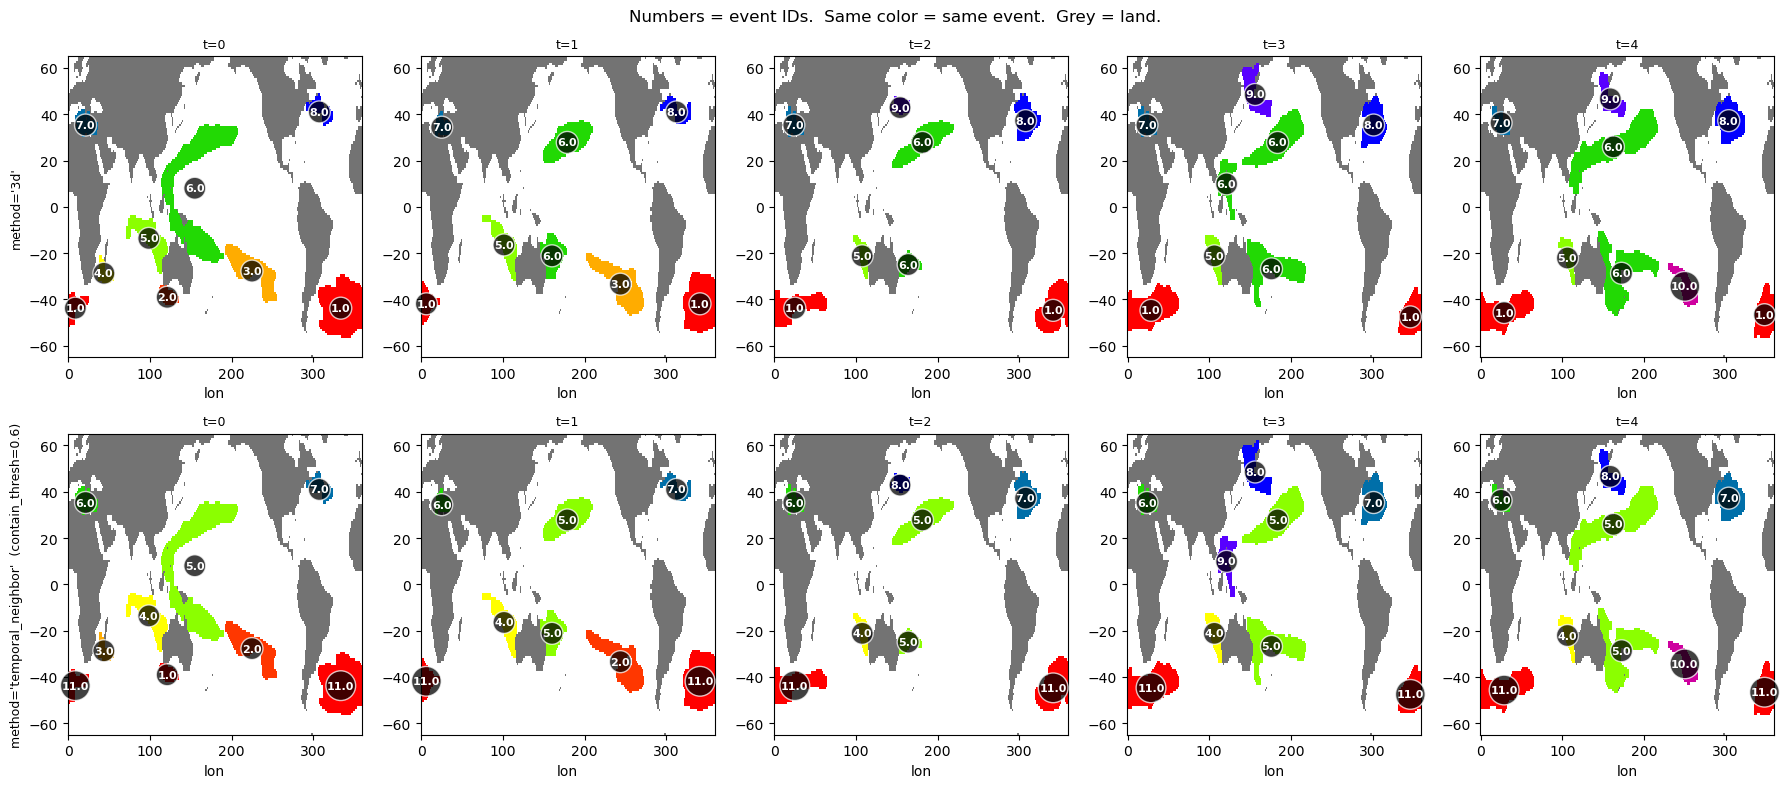

In [45]:
t_labels = [f't={t}' for t in range(0,5)]

rows = [
    (result_3d.values,  "method='3d'"),
    (result_tn.values,  "method='temporal_neighbor'  (contain_thresh=0.6)"),
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row, (labels, row_label) in enumerate(rows):
    for col in range(5):
        plot_labels_with_event_ids(
            axes[row, col], labels[col], t_labels[col], lon, lat, mask_2d
        )
    axes[row, 0].set_ylabel(row_label, fontsize=9)

fig.suptitle(
    'Numbers = event IDs.  Same color = same event.  Grey = land.',
    fontsize=12,
)
plt.tight_layout()
plt.show()

### 8. Events per timestep

How many distinct events are active at each month?


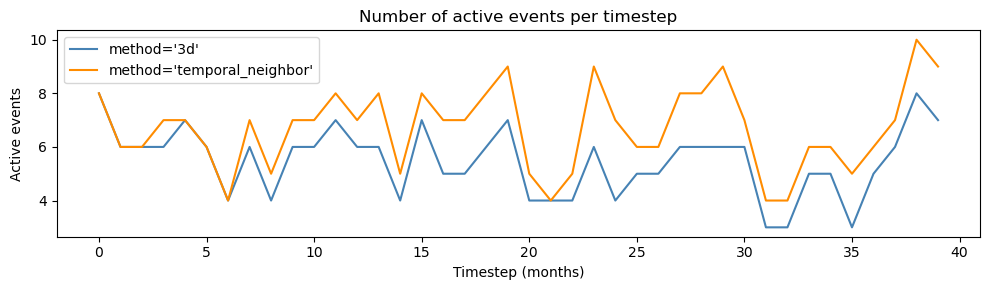

In [46]:
def count_per_timestep(result):
    return [
        len(np.unique(result.isel(time=t).values[
            ~np.isnan(result.isel(time=t).values)
        ]))
        for t in range(result.shape[0])
    ]

n_per_t_tn = count_per_timestep(result_tn)
n_per_t_3d = count_per_timestep(result_3d)
times       = np.arange(result_tn.shape[0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(times, n_per_t_3d, label="method='3d'",               color='steelblue', linewidth=1.5)
ax.plot(times, n_per_t_tn, label="method='temporal_neighbor'", color='darkorange', linewidth=1.5)
ax.set_xlabel('Timestep (months)')
ax.set_ylabel('Active events')
ax.set_title('Number of active events per timestep')
ax.legend()
plt.tight_layout()
plt.show()

### 9. Event duration distribution

How long do events last? `temporal_neighbor` with a strict `contain_thresh` tends
to produce more short-lived events because gaps and low-overlap transitions that
`label_3d` bridges become breakpoints.


Method                               Events   min  median   max
-----------------------------------------------------------------
temporal_neighbor (thresh=0.6)          103     1       1    20
3d                                       60     1       1    22


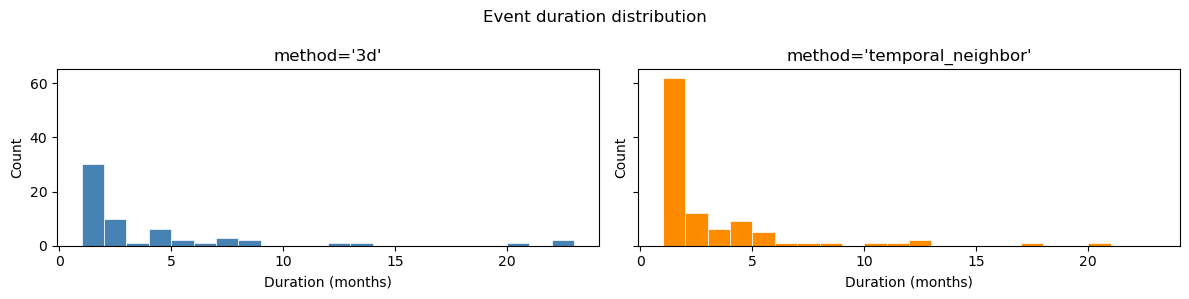

In [47]:
durs_tn = np.array(list(tracker_tn.event_duration().values()))
durs_3d = np.array(list(tracker_3d.event_duration().values()))

print(f"{'Method':<35} {'Events':>7}  {'min':>4}  {'median':>6}  {'max':>4}")
print("-" * 65)
print(f"{'temporal_neighbor (thresh=0.6)':<35} {len(durs_tn):>7}  "
      f"{durs_tn.min():>4}  {int(np.median(durs_tn)):>6}  {durs_tn.max():>4}")
print(f"{'3d':<35} {len(durs_3d):>7}  "
      f"{durs_3d.min():>4}  {int(np.median(durs_3d)):>6}  {durs_3d.max():>4}")

max_dur = max(durs_tn.max(), durs_3d.max())
bins    = range(1, max_dur + 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, durs, label, color in [
    (axes[0], durs_3d, "method='3d'",               'steelblue'),
    (axes[1], durs_tn, "method='temporal_neighbor'", 'darkorange'),
]:
    ax.hist(durs, bins=bins, color=color, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Duration (months)')
    ax.set_ylabel('Count')
    ax.set_title(label)
plt.suptitle('Event duration distribution')
plt.tight_layout()
plt.show()

### 10. Sensitivity to `contain_thresh`

Higher `contain_thresh` = stricter overlap requirement = less merging = more events.
`contain_thresh=0.0` (any overlap merges) is the most permissive setting.


In [48]:
thresholds = [0.0, 0.2, 0.4, 0.6, 0.8]
event_counts = []

base = SurfTracker(
    features, mask,
    radius=2, min_size_quartile=0.25, min_area_cells=100,
    timedim='time', xdim='lon', ydim='lat',
    method='temporal_neighbor', contain_thresh=0.0,
)
base.clean()
base.filter()

for thresh in thresholds:
    t = SurfTracker(
        features, mask,
        radius=2, min_size_quartile=0.25, min_area_cells=100,
        timedim='time', xdim='lon', ydim='lat',
        method='temporal_neighbor', contain_thresh=thresh,
    )
    t.binary_clean    = base.binary_clean
    t.binary_filtered = base.binary_filtered
    t.area            = base.area
    t.min_area        = base.min_area
    t.N_initial       = base.N_initial
    t.track()
    t.postprocess()
    event_counts.append(t.n_events())
    print(f"  contain_thresh={thresh:.1f}  →  {t.n_events()} events")

n_3d_ref = tracker_3d.n_events()
print(f"  method='3d'         →  {n_3d_ref} events")

Step 1 · morphological cleaning …
    fraction flagged = 0.1022  (OK)
Step 2 · area filtering …
area threshold : 100 cells  (floor=100, percentile=22.0)
Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 63
Step 4 · wrapping result …
  contain_thresh=0.0  →  63 events
Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 67
Step 4 · wrapping result …
  contain_thresh=0.2  →  67 events
Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 75
Step 4 · wrapping result …
  contain_thresh=0.4  →  75 events
Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 103
Step 4 · wrapping result …
  contain_thresh=0.6  →  103 events
Step 3 · labelling (method='temporal_neighbor') …
    initial objects : 791
    final objects   : 163
Step 4 · wrapping result …
  contain_thresh=0.8  →  163 events
  method='3d'         →  60 

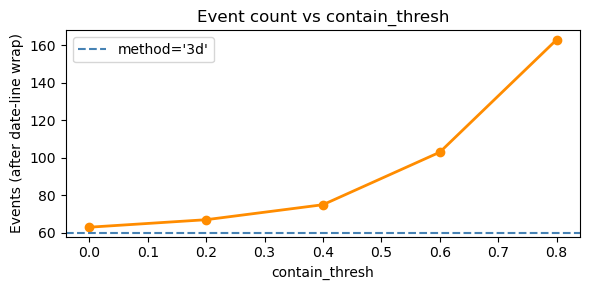

In [49]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(thresholds, event_counts, 'o-', color='darkorange', linewidth=2, markersize=6)
ax.axhline(n_3d_ref, color='steelblue', linestyle='--', linewidth=1.5, label="method='3d'")
ax.set_xlabel('contain_thresh')
ax.set_ylabel('Events (after date-line wrap)')
ax.set_title('Event count vs contain_thresh')
ax.legend()
plt.tight_layout()
plt.show()